In [1]:
import numpy as np

print(np.random.uniform(low=-1.0, high=1.0, size=5))
print(np.random.uniform(low=-1.0, high=1.0, size=(2, 3)))

[-0.67055191 -0.72736821 -0.22868012  0.71370765  0.22886755]
[[-0.201856    0.8363786   0.33227609]
 [ 0.54750427 -0.51160777 -0.15898894]]


In [2]:
X = np.random.uniform(low=-1.0, high=1.0, size=10)
Y = np.random.uniform(low=-1.0, high=1.0, size=10)
print(X)
print(Y)

[-0.30879553 -0.02810647 -0.24487785  0.71597128  0.69743244 -0.23973726
  0.52680899  0.57072444  0.17023537 -0.45887281]
[ 0.80941134 -0.91153367 -0.83717383 -0.32630709  0.40881786  0.08874042
  0.94306893 -0.50149512  0.41753724 -0.24005425]


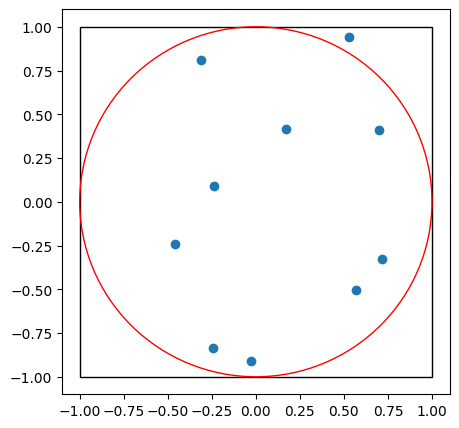

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(5, 5))
r = patches.Rectangle(xy=(-1, -1), width=2.0, height=2.0, fill=False, ec="k")
c = patches.Circle(xy=(0, 0), radius=1, fill=False,ec="r")
ax.add_patch(r)
ax.add_patch(c)
ax.scatter(X, Y)

In [4]:
I = []
for x, y in zip(X, Y):
    I.append(x * x + y * y <= 1)
print(I)

[np.True_, np.True_, np.True_, np.True_, np.True_, np.True_, np.False_, np.True_, np.True_, np.True_]


In [5]:
I = X * X + Y * Y <= 1
print(I)

[ True  True  True  True  True  True False  True  True  True]


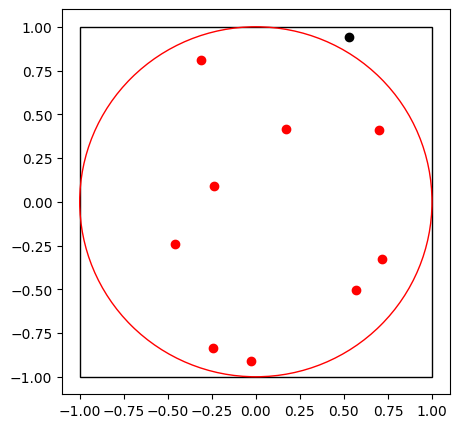

In [6]:
IX = []
IY = []
OX = []
OY = []
for x, y, inner in zip(X, Y, I):
    if inner:
        IX.append(x)
        IY.append(y)
    else:
        OX.append(x)
        OY.append(y)

fig, ax = plt.subplots(figsize=(5, 5))
r = patches.Rectangle(xy=(-1, -1), width=2.0, height=2.0, fill=False, ec="k")
c = patches.Circle(xy=(0, 0), radius=1, fill=False,ec="r")
ax.add_patch(r)
ax.add_patch(c)
ax.scatter(IX, IY, c="r")
ax.scatter(OX, OY, c="k")

In [7]:
ma = np.ma.array(data=[1, 2, 3], mask=[False, True, False])
print(ma)
print(np.sum(ma))

[1 -- 3]
4


In [8]:
X_outer = np.ma.array(X, mask=I)
print(X)
print(X_outer)

[-0.30879553 -0.02810647 -0.24487785  0.71597128  0.69743244 -0.23973726
  0.52680899  0.57072444  0.17023537 -0.45887281]
[-- -- -- -- -- -- 0.5268089917275507 -- -- --]


In [9]:
print(I)
print(~I)
print()
X_inner = np.ma.array(X, mask=~I)
print(X)
print(X_inner)

[ True  True  True  True  True  True False  True  True  True]
[False False False False False False  True False False False]

[-0.30879553 -0.02810647 -0.24487785  0.71597128  0.69743244 -0.23973726
  0.52680899  0.57072444  0.17023537 -0.45887281]
[-0.3087955278719061 -0.02810647135091693 -0.2448778462923149
 0.7159712825357611 0.6974324374039698 -0.23973725640451948 --
 0.5707244381212662 0.17023537223780005 -0.45887281453520856]


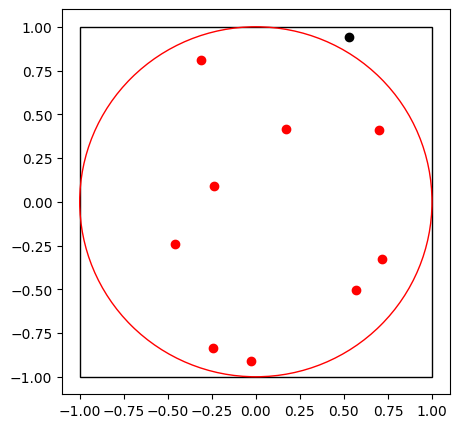

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
r = patches.Rectangle(xy=(-1, -1), width=2.0, height=2.0, fill=False, ec="k")
c = patches.Circle(xy=(0, 0), radius=1, fill=False,ec="r")
ax.add_patch(r)
ax.add_patch(c)
ax.scatter(X_inner, Y, c="r")
ax.scatter(X_outer, Y, c="k")

In [11]:
i = np.count_nonzero(I)
print(i)

9


In [12]:
n = 10
mc_pi = 4 * i / n
print(f"mc_pi = {mc_pi}")
print(f"np.pi = {np.pi}")
print(f"誤差  = {mc_pi - np.pi}") 

mc_pi = 3.6
np.pi = 3.141592653589793
誤差  = 0.458407346410207


In [13]:
def calc_mc_pi(num):
    print(f"点の個数 = {num}")
    X = np.random.uniform(low=-1.0, high=1.0, size=num)
    Y = np.random.uniform(low=-1.0, high=1.0, size=num)    
    I = X * X + Y * Y <= 1
    i = np.count_nonzero(I)
    mc_pi = 4 * i / num
    print(f"mc_pi = {mc_pi}")
    print(f"np.pi = {np.pi}")
    print(f"誤差  = {mc_pi - np.pi}")     

    X_inner = np.ma.array(data=X, mask=~I)
    X_outer = np.ma.array(data=X, mask=I)
    fig, ax = plt.subplots(figsize=(5, 5))
    r = patches.Rectangle(xy=(-1, -1), width=2.0, height=2.0, fill=False, ec="k")
    c = patches.Circle(xy=(0, 0), radius=1, fill=False,ec="r")
    ax.add_patch(r)
    ax.add_patch(c)
    ax.scatter(X_inner, Y, c="r")
    ax.scatter(X_outer, Y, c="k")

点の個数 = 10
mc_pi = 3.2
np.pi = 3.141592653589793
誤差  = 0.05840734641020706
点の個数 = 100
mc_pi = 3.2
np.pi = 3.141592653589793
誤差  = 0.05840734641020706
点の個数 = 1000
mc_pi = 3.192
np.pi = 3.141592653589793
誤差  = 0.050407346410207055
点の個数 = 10000
mc_pi = 3.1404
np.pi = 3.141592653589793
誤差  = -0.0011926535897930357
点の個数 = 100000
mc_pi = 3.1322
np.pi = 3.141592653589793
誤差  = -0.00939265358979302
点の個数 = 1000000
mc_pi = 3.140156
np.pi = 3.141592653589793
誤差  = -0.0014366535897929467


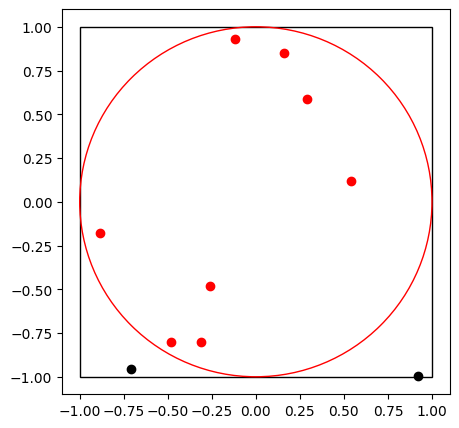

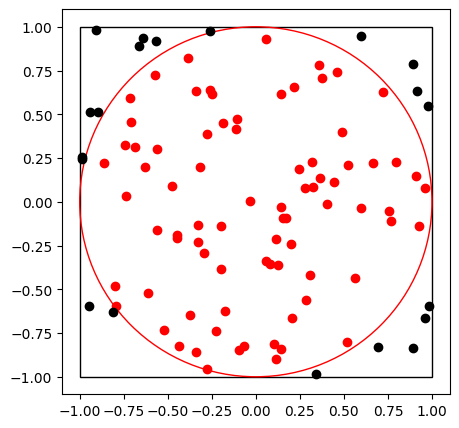

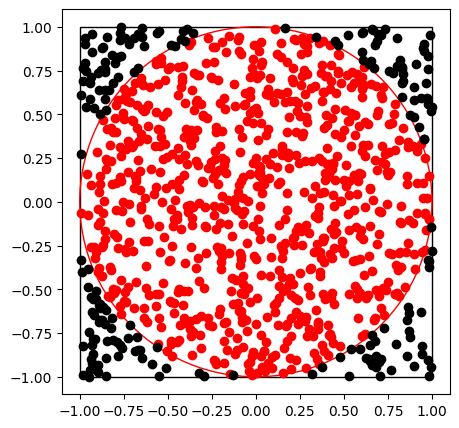

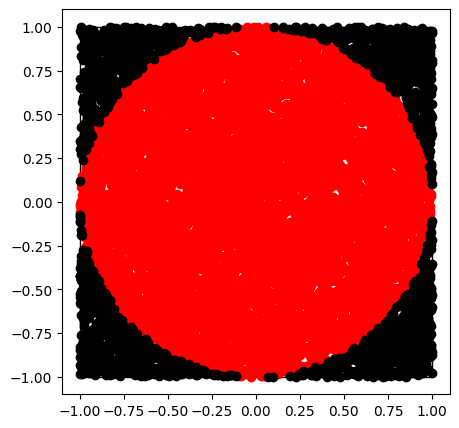

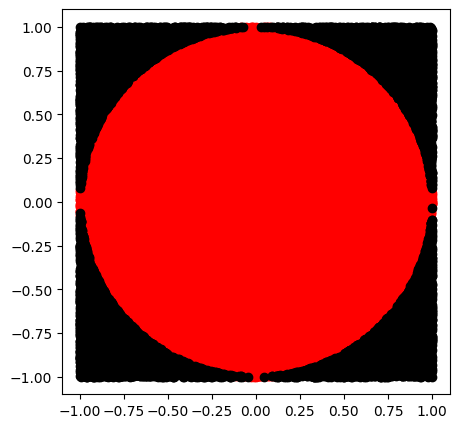

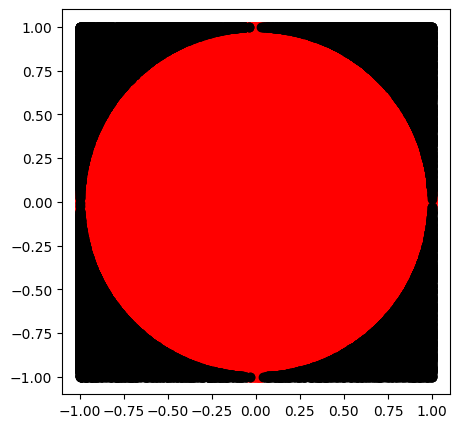

In [14]:
for num in [10, 100, 1000, 10000, 100000, 1000000]:
    calc_mc_pi(num)

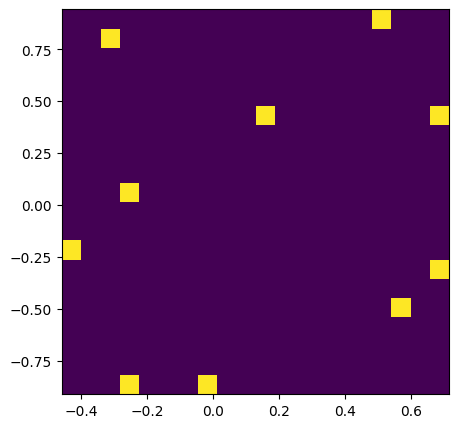

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist2d(X, Y, bins=20);

In [16]:
print(min(X), max(X))

-0.45887281453520856 0.7159712825357611


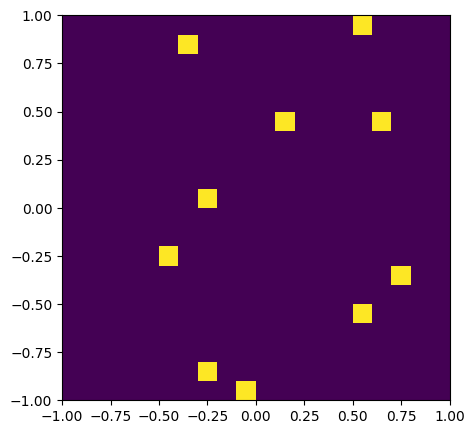

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]]);

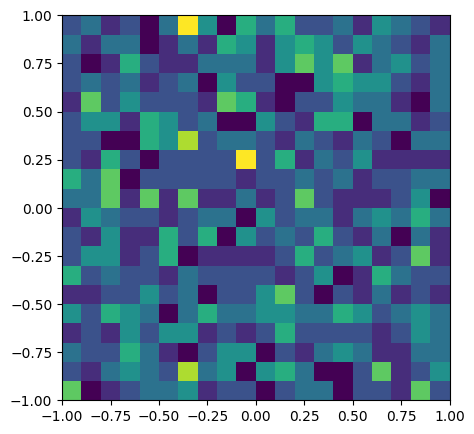

In [18]:
X = np.random.uniform(low=-1.0, high=1.0, size=1000)
Y = np.random.uniform(low=-1.0, high=1.0, size=1000) 
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]]);

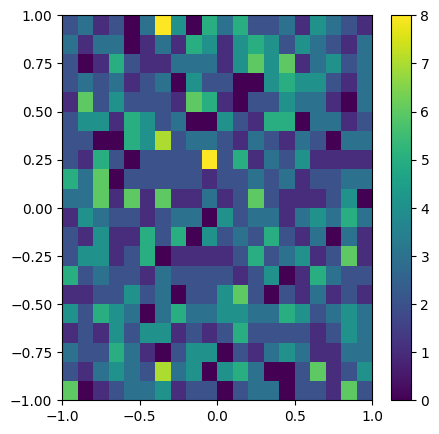

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
h = ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]])
fig.colorbar(h[3])

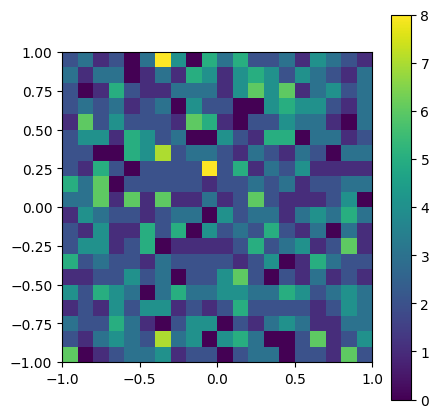

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
h = ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]])
fig.colorbar(h[3])
ax.set_aspect("equal")

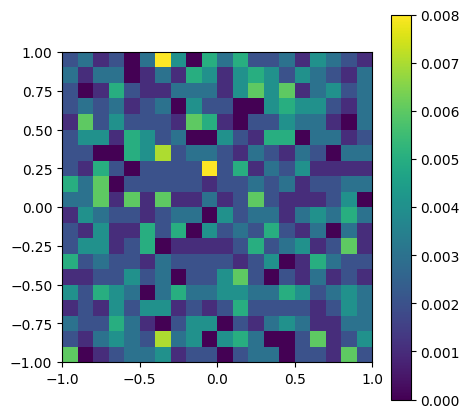

In [21]:
fig, ax = plt.subplots(figsize=(5, 5))
weights = np.full((1000, ), 1 / 1000)
h = ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]], weights=weights)
fig.colorbar(h[3])
ax.set_aspect("equal")

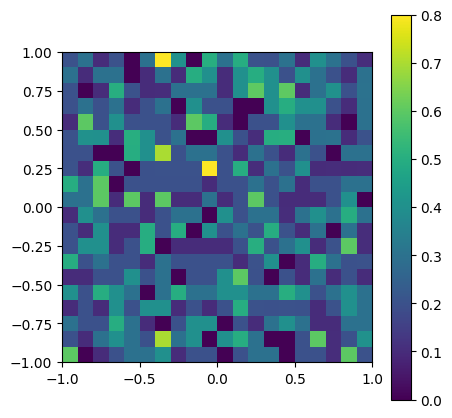

In [22]:
fig, ax = plt.subplots(figsize=(5, 5))
h = ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]], density=True)
fig.colorbar(h[3])
ax.set_aspect("equal")

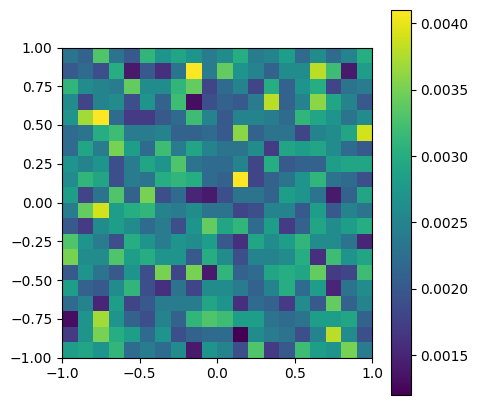

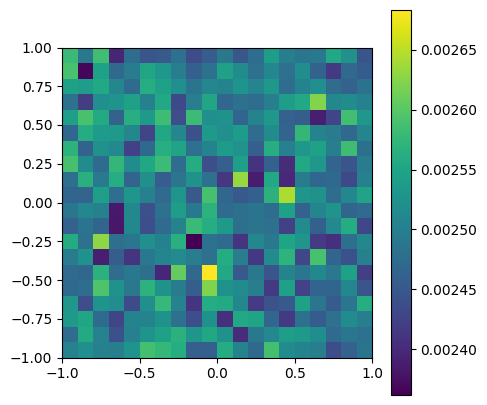

In [23]:
for size in [10000, 1000000]:
    X = np.random.uniform(low=-1.0, high=1.0, size=size)
    Y = np.random.uniform(low=-1.0, high=1.0, size=size) 
    fig, ax = plt.subplots(figsize=(5, 5))
    weights = np.full((size, ), 1 / size)
    h = ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]], weights=weights)
    fig.colorbar(h[3])
    ax.set_aspect("equal")

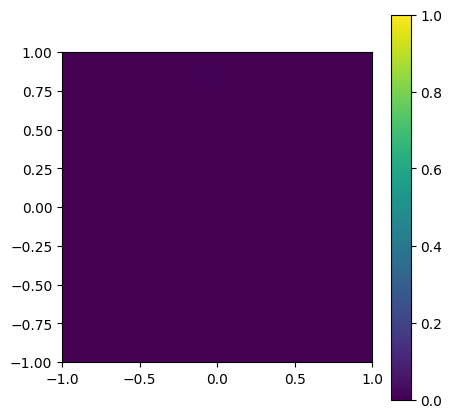

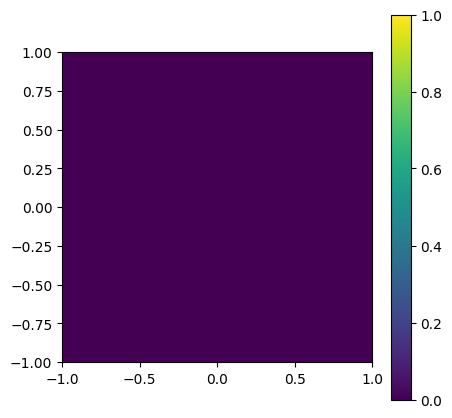

In [24]:
for size in [10000, 1000000]:
    X = np.random.uniform(low=-1.0, high=1.0, size=size)
    Y = np.random.uniform(low=-1.0, high=1.0, size=size) 
    fig, ax = plt.subplots(figsize=(5, 5))
    weights = np.full((size, ), 1 / size)
    h = ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]], weights=weights, vmin=0, vmax=1)
    fig.colorbar(h[3])
    ax.set_aspect("equal")

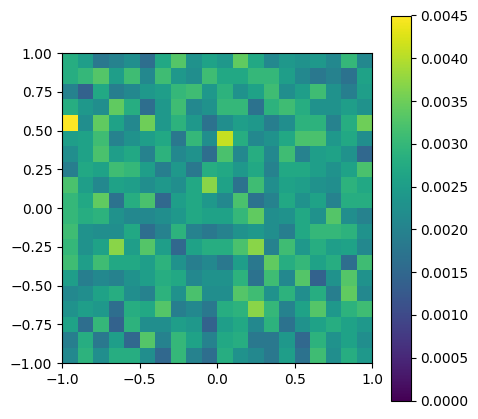

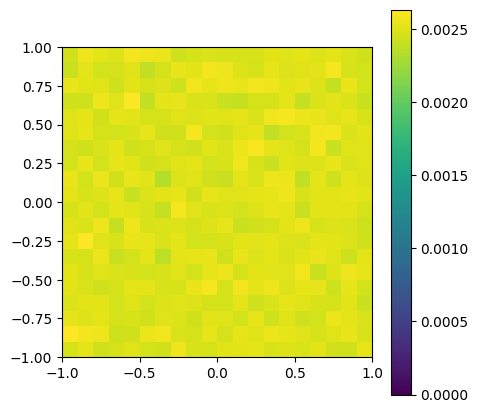

In [25]:
for size in [10000, 1000000]:
    X = np.random.uniform(low=-1.0, high=1.0, size=size)
    Y = np.random.uniform(low=-1.0, high=1.0, size=size) 
    fig, ax = plt.subplots(figsize=(5, 5))
    weights = np.full((size, ), 1 / size)
    h = ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]], weights=weights, vmin=0)
    fig.colorbar(h[3])
    ax.set_aspect("equal")

In [26]:
h = ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]], weights=weights, vmin=0)
print(h[0])

[[0.002466 0.002619 0.002528 0.002483 0.002522 0.002518 0.002472 0.002528
  0.002509 0.002466 0.002531 0.002548 0.002452 0.002461 0.002505 0.002512
  0.002448 0.002547 0.002417 0.002448]
 [0.002533 0.002594 0.002495 0.002513 0.002482 0.002478 0.002467 0.002636
  0.002487 0.002515 0.002474 0.002459 0.002547 0.002449 0.002539 0.002532
  0.002431 0.002515 0.002526 0.002568]
 [0.002446 0.00257  0.002526 0.00252  0.002447 0.002512 0.002556 0.002509
  0.002566 0.002454 0.002499 0.002555 0.002451 0.002486 0.002462 0.002449
  0.002573 0.002504 0.002457 0.002526]
 [0.002463 0.002437 0.002463 0.002454 0.002468 0.002491 0.002418 0.002481
  0.002401 0.002526 0.002539 0.002444 0.00254  0.002526 0.002454 0.002527
  0.002512 0.002431 0.002463 0.002492]
 [0.002507 0.002443 0.002477 0.002506 0.002533 0.002474 0.002457 0.002549
  0.002574 0.002509 0.002425 0.002547 0.002518 0.002446 0.002475 0.002513
  0.002617 0.002518 0.002512 0.002586]
 [0.002454 0.002554 0.002446 0.002452 0.002526 0.002458 0.002526 

2.5469999999999923e-07
2.5100100000006664e-09


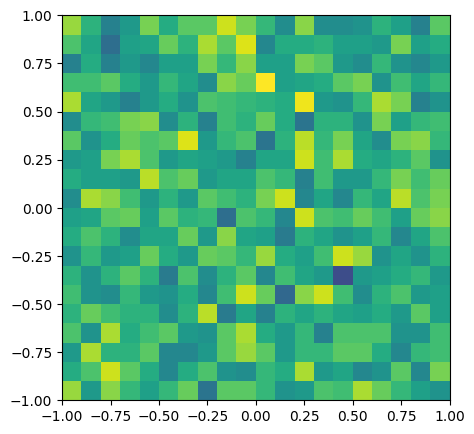

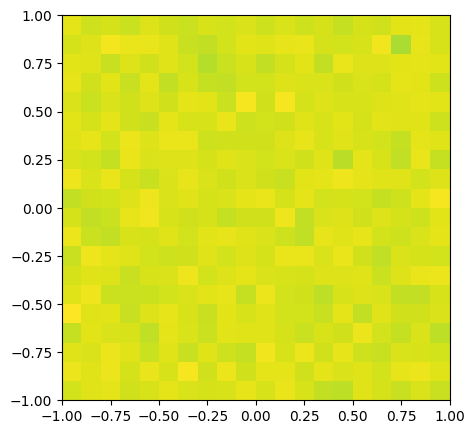

In [31]:
for size in [10000, 1000000]:
    X = np.random.uniform(low=-1.0, high=1.0, size=size)
    Y = np.random.uniform(low=-1.0, high=1.0, size=size) 
    fig, ax = plt.subplots(figsize=(5, 5))
    weights = np.full((size, ), 1 / size)
    h = ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]], weights=weights, vmin=0)
    print(np.var(h[0]))

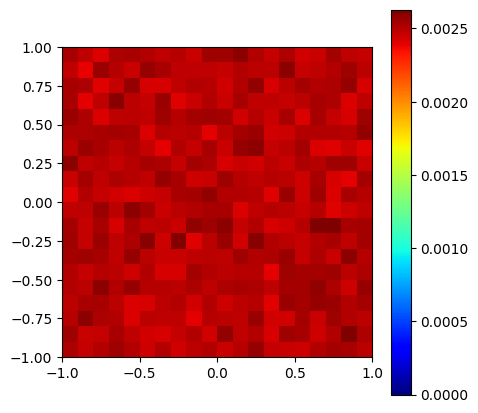

In [28]:
X = np.random.uniform(low=-1.0, high=1.0, size=size)
Y = np.random.uniform(low=-1.0, high=1.0, size=size) 
fig, ax = plt.subplots(figsize=(5, 5))
weights = np.full((size, ), 1 / size)
h = ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]], weights=weights, vmin=0, cmap="jet")
fig.colorbar(h[3])
ax.set_aspect("equal")

In [29]:
def calc_mc_pi(num):
    print(f"点の個数 = {num}")
    X = np.random.uniform(low=-1.0, high=1.0, size=num)
    Y = np.random.uniform(low=-1.0, high=1.0, size=num)    
    I = X * X + Y * Y <= 1
    i = np.count_nonzero(I)
    mc_pi = 4 * i / num
    print(f"mc_pi = {mc_pi}")
    print(f"np.pi = {np.pi}")
    print(f"誤差  = {mc_pi - np.pi}")     

    X_inner = np.ma.array(data=X, mask=~I)
    X_outer = np.ma.array(data=X, mask=I)
    fig, ax = plt.subplots(figsize=(5, 5))
    r = patches.Rectangle(xy=(-1, -1), width=2.0, height=2.0, fill=False, ec="k")
    c = patches.Circle(xy=(0, 0), radius=1, fill=False,ec="r")
    ax.add_patch(r)
    ax.add_patch(c)
    ax.scatter(X_inner, Y, c="r")
    ax.scatter(X_outer, Y, c="k")
    
    fig, ax = plt.subplots(figsize=(5, 5))
    weights = np.full((num, ), 1 / num)
    h = ax.hist2d(X, Y, bins=20, range=[[-1, 1], [-1, 1]], weights=weights, vmin=0, cmap="jet")
    fig.colorbar(h[3])
    ax.set_aspect("equal")
    print(f"分散  = {np.var(h[0])}")

点の個数 = 10
mc_pi = 3.6
np.pi = 3.141592653589793
誤差  = 0.458407346410207
分散  = 0.00024374999999999993
点の個数 = 100
mc_pi = 2.96
np.pi = 3.141592653589793
誤差  = -0.18159265358979315
分散  = 2.775e-05
点の個数 = 1000
mc_pi = 3.26
np.pi = 3.141592653589793
誤差  = 0.11840734641020667
分散  = 2.3950000000000004e-06
点の個数 = 10000
mc_pi = 3.1496
np.pi = 3.141592653589793
誤差  = 0.00800734641020684
分散  = 2.4224999999999925e-07
点の個数 = 100000
mc_pi = 3.14576
np.pi = 3.141592653589793
誤差  = 0.004167346410206996
分散  = 2.387050000000012e-08
点の個数 = 1000000
mc_pi = 3.141392
np.pi = 3.141592653589793
誤差  = -0.0002006535897929318
分散  = 2.433290000000646e-09


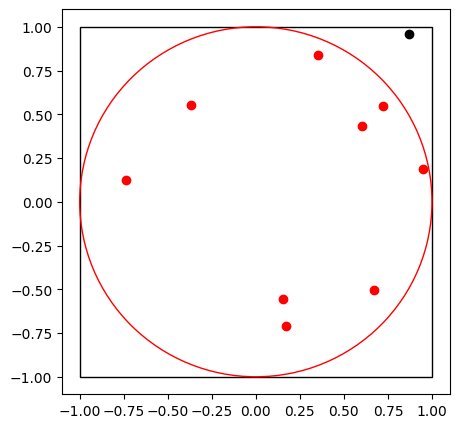

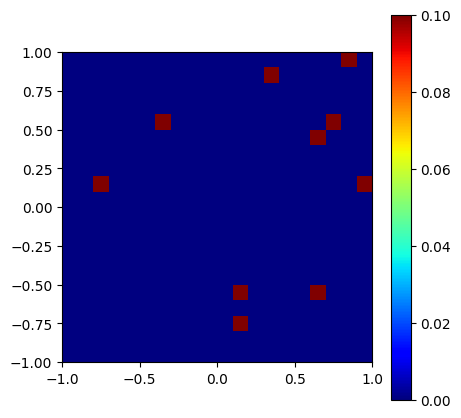

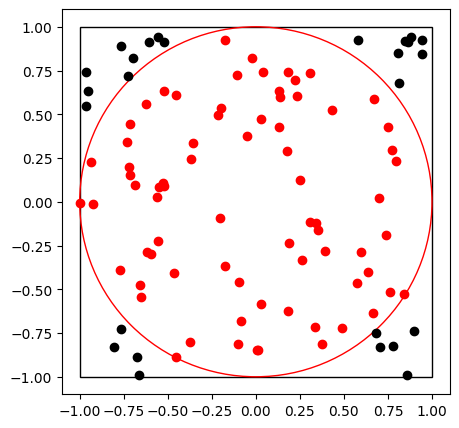

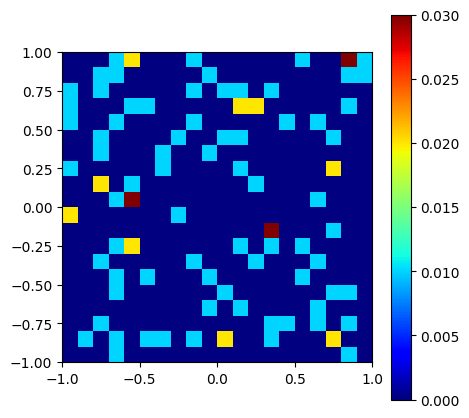

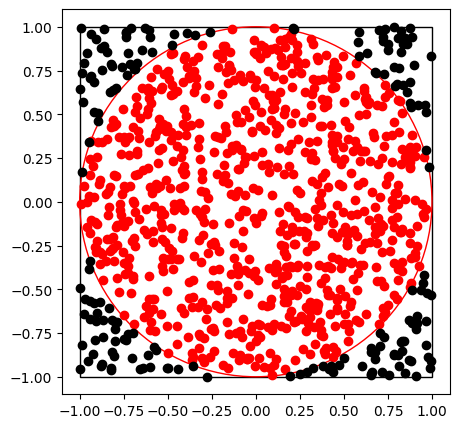

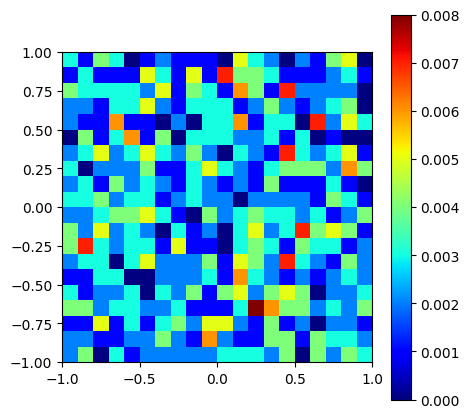

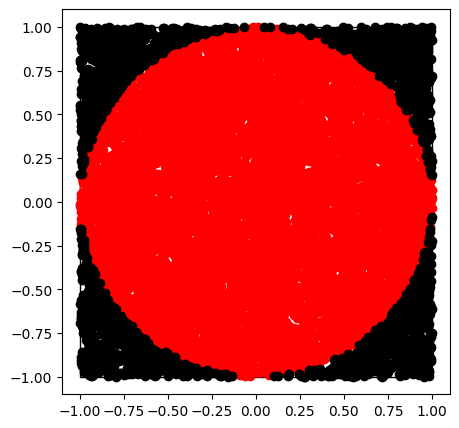

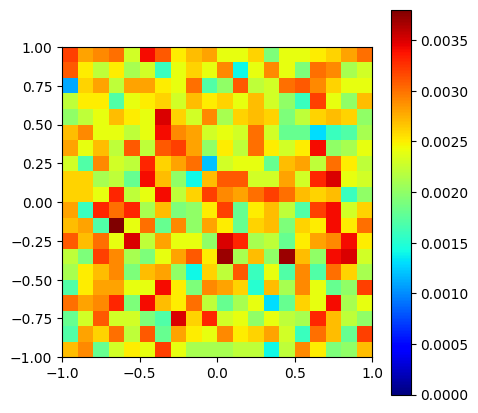

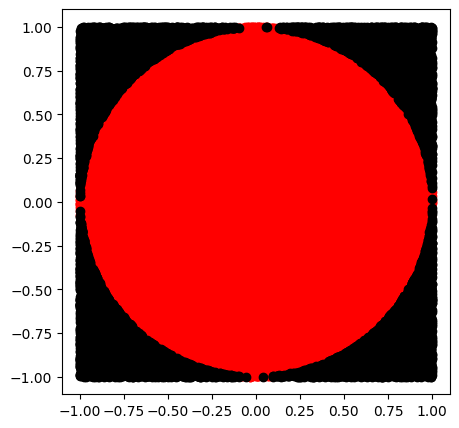

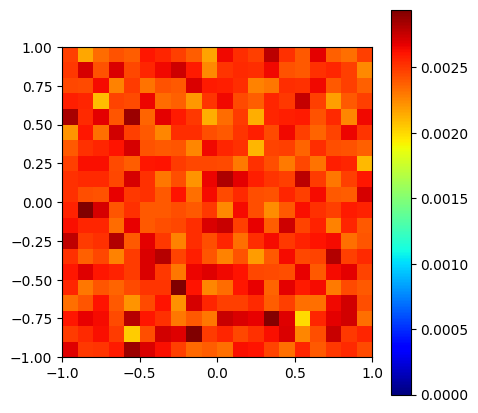

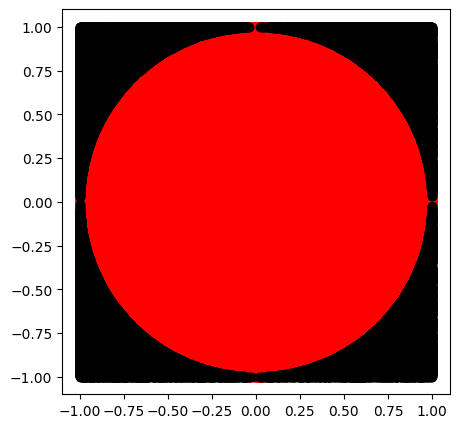

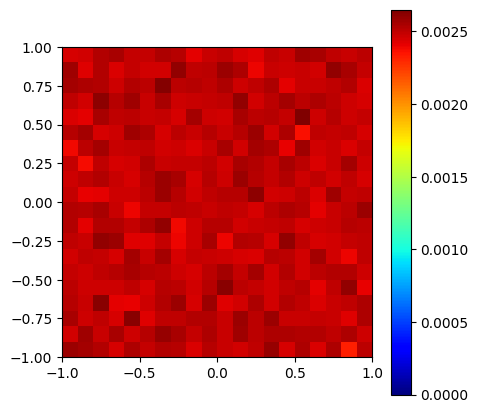

In [30]:
for num in [10, 100, 1000, 10000, 100000, 1000000]:
    calc_mc_pi(num)